# Visualization Only

`all_clean` / `vif_clean`의 **plt.savefig 시각화 11종×2**만 재생성.

- 데이터: `data/raw/sensor.csv`
- 체크포인트: `models/checkpoints_all/`, `models/checkpoints_vif/`
- 출력: `outputs/figures/all/`, `outputs/figures/vif/`
- 학습·Optuna·Gradio 없음


In [19]:
# Visualization only — checkpoints + sensor.csv (no training / Optuna / Gradio)
import os
import re
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.gridspec as gridspec
import platform
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import (
    f1_score, fbeta_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)

import torch
import torch.nn as nn

warnings.filterwarnings('ignore')

_cwd = Path.cwd().resolve()
REPO_ROOT = _cwd if (_cwd / 'data' / 'raw' / 'sensor.csv').is_file() else _cwd.parents[1]
os.chdir(REPO_ROOT)

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    fm._load_fontmanager(try_read_cache=False)
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = str(REPO_ROOT / 'data' / 'raw' / 'sensor.csv')
if not os.path.isfile(DATA_PATH):
    raise FileNotFoundError(f'sensor.csv 없음: {DATA_PATH}')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

WINDOW_SIZE = 50
STEP_SIZE = 10
THRESHOLD_PCT = 95
MISSING_THRESH = 0.50
DEFAULT_HIDDEN = 64
DEFAULT_LATENT = 32
DEFAULT_LAYERS = 2
DEFAULT_DROPOUT = 0.1
plot_colors = ['#6366F1', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6']

print(f'REPO_ROOT: {REPO_ROOT}')
print(f'DATA_PATH: {DATA_PATH}')
print(f'Device: {device}')


REPO_ROOT: D:\Large Language Model\sensor_anomaly
DATA_PATH: D:\Large Language Model\sensor_anomaly\data\raw\sensor.csv
Device: cpu


In [20]:
# Utils: load_deep_model은 .pt state_dict shape으로 hidden/latent/layers 추정

class LSTMAutoencoder(nn.Module):
    def __init__(self, n_feat, hidden=64, latent=32, layers=2, dropout=0.1, **kw):
        super().__init__()
        self.model_name = 'LSTM-AE'
        drop = dropout if layers > 1 else 0
        self.enc = nn.LSTM(n_feat, hidden, layers, batch_first=True, dropout=drop)
        self.fc_e = nn.Linear(hidden, latent)
        self.fc_d = nn.Linear(latent, hidden)
        self.dec = nn.LSTM(hidden, hidden, layers, batch_first=True, dropout=drop)
        self.out = nn.Linear(hidden, n_feat)

    def forward(self, x):
        _, (h, _) = self.enc(x)
        z = self.fc_e(h[-1])
        di = self.fc_d(z).unsqueeze(1).repeat(1, x.size(1), 1)
        dec, _ = self.dec(di)
        return self.out(dec)


class CNN1DAutoencoder(nn.Module):
    def __init__(self, n_feat, hidden=64, latent=32, dropout=0.1, **kw):
        super().__init__()
        self.model_name = 'CNN1D-AE'
        self.enc = nn.Sequential(
            nn.Conv1d(n_feat, hidden, 7, padding=3), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(hidden, hidden * 2, 5, padding=2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc_e = nn.Linear(hidden * 2, latent)
        self.fc_d = nn.Linear(latent, hidden * 2)
        self.dec = nn.Sequential(
            nn.ConvTranspose1d(hidden * 2, hidden, 5, padding=2), nn.ReLU(), nn.Dropout(dropout),
            nn.ConvTranspose1d(hidden, n_feat, 7, padding=3),
        )

    def forward(self, x):
        W = x.size(1)
        z = self.fc_e(self.enc(x.permute(0, 2, 1)).squeeze(-1))
        di = self.fc_d(z).unsqueeze(-1).repeat(1, 1, W)
        return self.dec(di).permute(0, 2, 1)


class TransformerAutoencoder(nn.Module):
    def __init__(self, n_feat, hidden=64, latent=32, nhead=4, layers=2, dropout=0.1, **kw):
        super().__init__()
        self.model_name = 'Transformer-AE'
        nhead = max(h for h in [1, 2, 4, 8] if hidden % h == 0 and h <= nhead)
        self.proj = nn.Linear(n_feat, hidden)
        enc_l = nn.TransformerEncoderLayer(hidden, nhead, hidden * 4, dropout, batch_first=True)
        self.tenc = nn.TransformerEncoder(enc_l, layers)
        self.fc_e = nn.Linear(hidden, latent)
        self.fc_d = nn.Linear(latent, hidden)
        dec_l = nn.TransformerDecoderLayer(hidden, nhead, hidden * 4, dropout, batch_first=True)
        self.tdec = nn.TransformerDecoder(dec_l, layers)
        self.out = nn.Linear(hidden, n_feat)

    def forward(self, x):
        p = self.proj(x)
        m = self.tenc(p)
        z = self.fc_e(m.mean(1))
        d = self.fc_d(z).unsqueeze(1).repeat(1, x.size(1), 1)
        return self.out(self.tdec(d, m))


DEEP_MODEL_CLASSES = {
    'LSTM-AE': LSTMAutoencoder,
    'CNN1D-AE': CNN1DAutoencoder,
    'Transformer-AE': TransformerAutoencoder,
}


def compute_vif(df_feat):
    X = df_feat.dropna().astype(float)
    return pd.DataFrame({
        'feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    }).sort_values('VIF', ascending=False).reset_index(drop=True)


def iterative_vif_drop(df_feat, threshold, verbose=True):
    remaining = list(df_feat.columns)
    step = 0
    while True:
        step += 1
        vif = compute_vif(df_feat[remaining])
        top_vif = vif.iloc[0]['VIF']
        top_feat = vif.iloc[0]['feature']
        if top_vif <= threshold:
            if verbose:
                print(f'  [step {step}] Done — all VIF <= {threshold}')
            break
        if verbose:
            print(f'  [step {step}] Drop {top_feat:<15s}  VIF={top_vif:.2f}')
        remaining.remove(top_feat)
    return remaining, pd.DataFrame()


def get_errors(model, X_tensor, batch=512):
    model.eval()
    errs = []
    with torch.no_grad():
        for i in range(0, len(X_tensor), batch):
            b = X_tensor[i:i + batch]
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                recon = model(b)
            errs.extend(((b - recon) ** 2).mean(dim=(1, 2)).cpu().numpy())
    return np.array(errs)


def evaluate(errors, y_true, pct=THRESHOLD_PCT):
    errors = np.nan_to_num(errors, nan=0.0, posinf=0.0, neginf=0.0)
    thr = np.percentile(errors, pct)
    y_pred = (errors > thr).astype(int)
    uniq = len(np.unique(y_true))
    return dict(
        threshold=thr,
        y_pred=y_pred,
        errors=errors,
        f1=f1_score(y_true, y_pred, zero_division=0),
        f2=fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        precision=precision_score(y_true, y_pred, zero_division=0),
        recall=recall_score(y_true, y_pred, zero_division=0),
        roc_auc=roc_auc_score(y_true, errors) if uniq > 1 else 0.0,
        pr_auc=average_precision_score(y_true, errors) if uniq > 1 else 0.0,
    )


def make_windows(data, labels, win, step):
    X, y = [], []
    for s in range(0, len(data) - win, step):
        X.append(data[s:s + win])
        y.append(int(labels[s:s + win].max()))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


def load_serving_config(checkpoint_dir):
    import json

    path = os.path.join(checkpoint_dir, 'model_serving_config.json')
    default = {
        'best_params': {
            'LSTM-AE': {'hidden': 64, 'latent': 32, 'layers': 2, 'dropout': 0.1},
            'CNN1D-AE': {'hidden': 64, 'latent': 32, 'layers': 2, 'dropout': 0.1},
            'Transformer-AE': {'hidden': 64, 'latent': 32, 'layers': 2, 'dropout': 0.1},
        },
        'window_configs': {
            'LSTM-AE': {'window_size': 50, 'threshold_pct': 95},
            'CNN1D-AE': {'window_size': 50, 'threshold_pct': 95},
            'Transformer-AE': {'window_size': 50, 'threshold_pct': 95},
        },
        'step_size': 10,
    }
    if not os.path.isfile(path):
        return default
    with open(path, encoding='utf-8') as f:
        raw = json.load(f)
    for fam in ('best_params', 'window_configs'):
        if fam in raw:
            for k, v in raw[fam].items():
                default[fam].setdefault(k, {}).update(v)
    if 'step_size' in raw:
        default['step_size'] = int(raw['step_size'])
    return default


def _build_deep_model(model_name, n_feat, hidden, latent, layers, dropout):
    if model_name == 'Transformer-AE':
        return DEEP_MODEL_CLASSES[model_name](
            n_feat, hidden=hidden, latent=latent, layers=layers, dropout=dropout, nhead=4,
        )
    kw = dict(hidden=hidden, latent=latent, dropout=dropout)
    if model_name == 'LSTM-AE':
        kw['layers'] = layers
    return DEEP_MODEL_CLASSES[model_name](n_feat, **kw)


def _params_for_suffix(model_name, suffix, serving_cfg):
    """default.pt는 Sec.6 기본 하이퍼(DEFAULT_*); tuned/optuna_best는 serving JSON."""
    if suffix == 'default':
        return DEFAULT_HIDDEN, DEFAULT_LATENT, DEFAULT_LAYERS, DEFAULT_DROPOUT
    p = dict(serving_cfg['best_params'].get(model_name, {}))
    return (
        int(p.get('hidden', DEFAULT_HIDDEN)),
        int(p.get('latent', DEFAULT_LATENT)),
        int(p.get('layers', DEFAULT_LAYERS)),
        float(p.get('dropout', DEFAULT_DROPOUT)),
    )


def _dims_from_state_dict(model_name, state, serving_cfg, suffix):
    """가중치 텐서 shape에서 아키텍처 추정 (JSON/ suffix와 무관하게 .pt와 일치)."""
    if model_name == 'LSTM-AE' and 'enc.weight_ih_l0' in state:
        hidden = int(state['enc.weight_ih_l0'].shape[0] // 4)
        latent = int(state['fc_e.weight'].shape[0])
        layers = sum(1 for k in state if k.startswith('enc.weight_ih_l'))
        return hidden, latent, layers, DEFAULT_DROPOUT
    if model_name == 'CNN1D-AE' and 'enc.0.weight' in state:
        hidden = int(state['enc.0.weight'].shape[0])
        latent = int(state['fc_e.weight'].shape[0])
        return hidden, latent, DEFAULT_LAYERS, DEFAULT_DROPOUT
    if model_name == 'Transformer-AE' and 'proj.weight' in state:
        hidden = int(state['proj.weight'].shape[0])
        latent = int(state['fc_e.weight'].shape[0])
        n_layers = len({k.split('.')[1] for k in state if k.startswith('tenc.layers.')})
        layers = max(n_layers, DEFAULT_LAYERS)
        return hidden, latent, layers, DEFAULT_DROPOUT
    return _params_for_suffix(model_name, suffix, serving_cfg)


def load_deep_model(checkpoint_dir, model_name, suffix, n_feat, serving_cfg):
    pt = os.path.join(checkpoint_dir, f'{model_name}_{suffix}.pt')
    if not os.path.isfile(pt):
        return None
    try:
        state = torch.load(pt, map_location=device, weights_only=True)
    except TypeError:
        state = torch.load(pt, map_location=device)
    hidden, latent, layers, dropout = _dims_from_state_dict(
        model_name, state, serving_cfg, suffix
    )
    model = _build_deep_model(model_name, n_feat, hidden, latent, layers, dropout)
    model.load_state_dict(state)
    model.eval()
    return model.to(device)


def parse_optuna_log(log_path):
    trial_vals, best = [], None
    if not os.path.isfile(log_path):
        return trial_vals, best
    with open(log_path, encoding='utf-8', errors='replace') as f:
        for line in f:
            m = re.search(r'New best Val F2=([\d.]+)', line)
            if m:
                trial_vals.append(float(m.group(1)))
            m2 = re.search(r'Optuna Best Val F2\s*:\s*([\d.]+)', line)
            if m2:
                best = float(m2.group(1))
    return trial_vals, best


def prepare_variant(variant):
    global OUTPUT_DIR, CHECKPOINT_DIR, MODEL_DIR, VIF_THRESH, CORR_THRESH
    global df_vis, valid_sensors, FINAL_FEATURES, N_FEATURES, vif_before, vif_after
    global X_train_all, y_train_all, X_val_all, y_val_all, X_test, y_test
    global X_test_t, X_val_t, results, BEST_MODEL_NAME, serving_cfg
    global study_best_value, trial_vals, final_errors, final_metrics, y_te_fin

    if variant == 'all':
        OUTPUT_DIR = str(REPO_ROOT / 'outputs/figures/all/')
        CHECKPOINT_DIR = str(REPO_ROOT / 'models/checkpoints_all/')
        VIF_THRESH = 9999.0
        CORR_THRESH = 1.0
    else:
        OUTPUT_DIR = str(REPO_ROOT / 'outputs/figures/vif/')
        CHECKPOINT_DIR = str(REPO_ROOT / 'models/checkpoints_vif/')
        VIF_THRESH = 50.0
        CORR_THRESH = 0.98

    MODEL_DIR = CHECKPOINT_DIR
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    serving_cfg = load_serving_config(CHECKPOINT_DIR)

    feat_path = os.path.join(CHECKPOINT_DIR, 'final_features.pkl')
    scaler_path = os.path.join(CHECKPOINT_DIR, 'scaler.pkl')
    if not os.path.isfile(feat_path) or not os.path.isfile(scaler_path):
        raise FileNotFoundError(
            f'체크포인트에 scaler.pkl / final_features.pkl 필요: {CHECKPOINT_DIR}'
        )

    with open(feat_path, 'rb') as f:
        FINAL_FEATURES = pickle.load(f)
    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)
    N_FEATURES = len(FINAL_FEATURES)

    missing = df_raw[sensor_cols].isnull().mean().sort_values(ascending=False)
    drop_missing = missing[missing > MISSING_THRESH].index.tolist()
    valid_sensors = [c for c in sensor_cols if c not in drop_missing]
    df_vis = df_raw[valid_sensors + ['machine_status']].copy()

    vif_sample = df_vis[valid_sensors].dropna().sample(min(8000, len(df_vis)), random_state=SEED)
    vif_before = compute_vif(vif_sample)
    selected_by_vif, _ = iterative_vif_drop(vif_sample, VIF_THRESH, verbose=True)
    zero_var = [c for c in selected_by_vif if df_vis[c].std() < 1e-6]
    computed = [c for c in selected_by_vif if c not in zero_var]
    if set(computed) != set(FINAL_FEATURES):
        print(
            f'  [참고] VIF 재계산({len(computed)}) vs 체크포인트({N_FEATURES}) — 체크포인트 피처 사용'
        )
    vif_after = compute_vif(vif_sample[FINAL_FEATURES])

    df_proc = df_raw[FINAL_FEATURES + ['machine_status']].copy().reset_index(drop=True)
    label_map = {'NORMAL': 0, 'BROKEN': 1, 'RECOVERING': 1}
    df_proc['label'] = df_proc['machine_status'].map(label_map).fillna(0).astype(int)
    n = len(df_proc)
    i_tr, i_val = int(n * 0.55), int(n * 0.70)
    train_df = df_proc.iloc[:i_tr].copy()
    val_df = df_proc.iloc[i_tr:i_val].copy()
    test_df = df_proc.iloc[i_val:].copy()

    def _impute(df_part):
        df_part = df_part.copy()
        df_part[FINAL_FEATURES] = df_part[FINAL_FEATURES].ffill().fillna(0.0)
        return df_part

    train_df, val_df, test_df = _impute(train_df), _impute(val_df), _impute(test_df)

    def _safe_scaled(X):
        return np.nan_to_num(
            scaler.transform(X).astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0
        )

    train_scaled = _safe_scaled(train_df[FINAL_FEATURES])
    val_scaled = _safe_scaled(val_df[FINAL_FEATURES])
    test_scaled = _safe_scaled(test_df[FINAL_FEATURES])
    labels_train = train_df['label'].values
    labels_val = val_df['label'].values
    labels_test = test_df['label'].values

    win = WINDOW_SIZE
    step = serving_cfg.get('step_size', STEP_SIZE)
    X_train_all, y_train_all = make_windows(train_scaled, labels_train, win, step)
    X_val_all, y_val_all = make_windows(val_scaled, labels_val, win, step)
    X_test, y_test = make_windows(test_scaled, labels_test, win, step)
    X_test_t = torch.FloatTensor(X_test).to(device)
    X_val_t = torch.FloatTensor(X_val_all).to(device)

    results = {}
    for mname in DEEP_MODEL_CLASSES:
        model = load_deep_model(CHECKPOINT_DIR, mname, 'default', N_FEATURES, serving_cfg)
        if model is None:
            print(f'  skip (no .pt): {mname}_default.pt')
            continue
        met = evaluate(get_errors(model, X_test_t), y_test)
        met['val_f2'] = evaluate(get_errors(model, X_val_t), y_val_all)['f2']
        met['val_f1'] = evaluate(get_errors(model, X_val_t), y_val_all)['f1']
        met['val_pr_auc'] = evaluate(get_errors(model, X_val_t), y_val_all)['pr_auc']
        met['train_time'] = 0
        results[mname] = met

    if not results:
        raise FileNotFoundError(f'평가 가능한 *_default.pt 없음: {CHECKPOINT_DIR}')

    BEST_MODEL_NAME = max(results.keys(), key=lambda m: results[m]['val_f2'])

    logs = [f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('.log')]
    log_path = os.path.join(CHECKPOINT_DIR, logs[0]) if logs else ''
    trial_vals, study_best_value = parse_optuna_log(log_path)

    wc = serving_cfg['window_configs'].get(
        BEST_MODEL_NAME, {'window_size': win, 'threshold_pct': THRESHOLD_PCT}
    )
    tuned = load_deep_model(CHECKPOINT_DIR, BEST_MODEL_NAME, 'tuned', N_FEATURES, serving_cfg)
    if tuned is None:
        tuned = load_deep_model(
            CHECKPOINT_DIR, BEST_MODEL_NAME, 'optuna_best', N_FEATURES, serving_cfg
        )
    if tuned is None:
        tuned = load_deep_model(
            CHECKPOINT_DIR, BEST_MODEL_NAME, 'default', N_FEATURES, serving_cfg
        )
    final_errors = get_errors(tuned, X_test_t)
    final_metrics = evaluate(final_errors, y_test, pct=wc.get('threshold_pct', THRESHOLD_PCT))
    y_te_fin = y_test

    print(f'\n=== {variant.upper()} | OUT={OUTPUT_DIR} ===')
    print(f'CKPT={CHECKPOINT_DIR} | features={N_FEATURES} | BEST={BEST_MODEL_NAME}')


In [21]:
df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = df_raw.columns.str.strip()
ts_col = next((c for c in df_raw.columns if 'time' in c.lower()), None)
if ts_col:
    df_raw.rename(columns={ts_col: 'timestamp'}, inplace=True)
    df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
    df_raw = df_raw.set_index('timestamp').sort_index()
sensor_cols = [c for c in df_raw.columns if c.startswith('sensor')]
print(f'Shape: {df_raw.shape} | sensors: {len(sensor_cols)}')


Shape: (220320, 54) | sensors: 52


---
## ALL (51 sensors)


In [22]:
prepare_variant('all')


  [step 1] Done — all VIF <= 9999.0

=== ALL | OUT=D:\Large Language Model\sensor_anomaly\outputs\figures\all ===
CKPT=D:\Large Language Model\sensor_anomaly\models\checkpoints_all | features=51 | BEST=LSTM-AE


### ALL (51 sensors) — 01_missing_labels


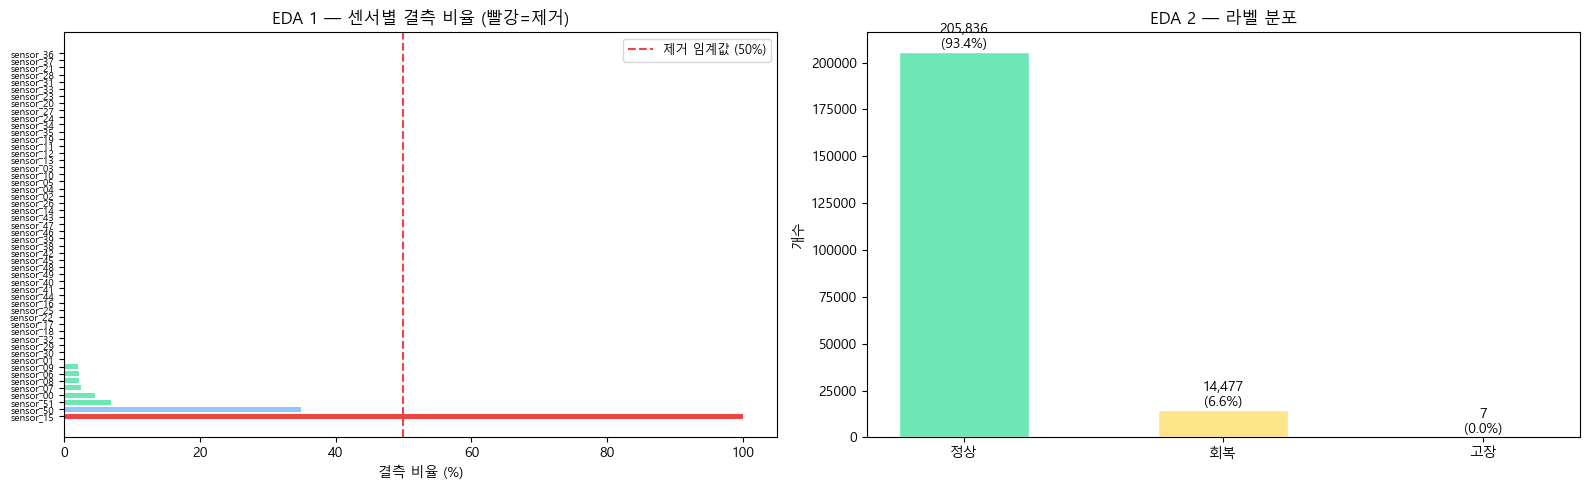

Dropped by missing: ['sensor_15']
Remaining sensors : 51


In [23]:
missing = df_raw[sensor_cols].isnull().mean().sort_values(ascending=False)
drop_missing = missing[missing > MISSING_THRESH].index.tolist()
valid_sensors = [c for c in sensor_cols if c not in drop_missing]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 결측률 바차트
ax = axes[0]
colors = ['#EF4444' if v > MISSING_THRESH else '#93C5FD' if v > 0.2 else '#6EE7B7'
          for v in missing.values]
ax.barh(missing.index, missing.values * 100, color=colors, height=0.7)
ax.axvline(MISSING_THRESH * 100, color='#EF4444', linestyle='--', lw=1.5,
           label=f'제거 임계값 ({int(MISSING_THRESH*100)}%)')
ax.set_xlabel('결측 비율 (%)')
ax.set_title('EDA 1 — 센서별 결측 비율 (빨강=제거)')
ax.legend(fontsize=9)
ax.tick_params(axis='y', labelsize=7)

# 레이블 분포
vc = df_raw['machine_status'].value_counts()
label_ko = {'NORMAL': '정상', 'BROKEN': '고장', 'RECOVERING': '회복'}
bar_col = {'NORMAL':'#6EE7B7', 'BROKEN':'#FCA5A5', 'RECOVERING':'#FDE68A'}
ax2 = axes[1]
ax2.bar([label_ko.get(str(k), str(k)) for k in vc.index], vc.values,
        color=[bar_col.get(str(k),'#CBD5E1') for k in vc.index], edgecolor='white', width=0.5)
for i,(k,v) in enumerate(vc.items()):
    ax2.text(i, v+500, f'{v:,}\n({v/len(df_raw)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10)
ax2.set_title('EDA 2 — 라벨 분포')
ax2.set_ylabel('개수')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_missing_labels.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Dropped by missing: {drop_missing}')
print(f'Remaining sensors : {len(valid_sensors)}')


### ALL (51 sensors) — 02_all_sensors


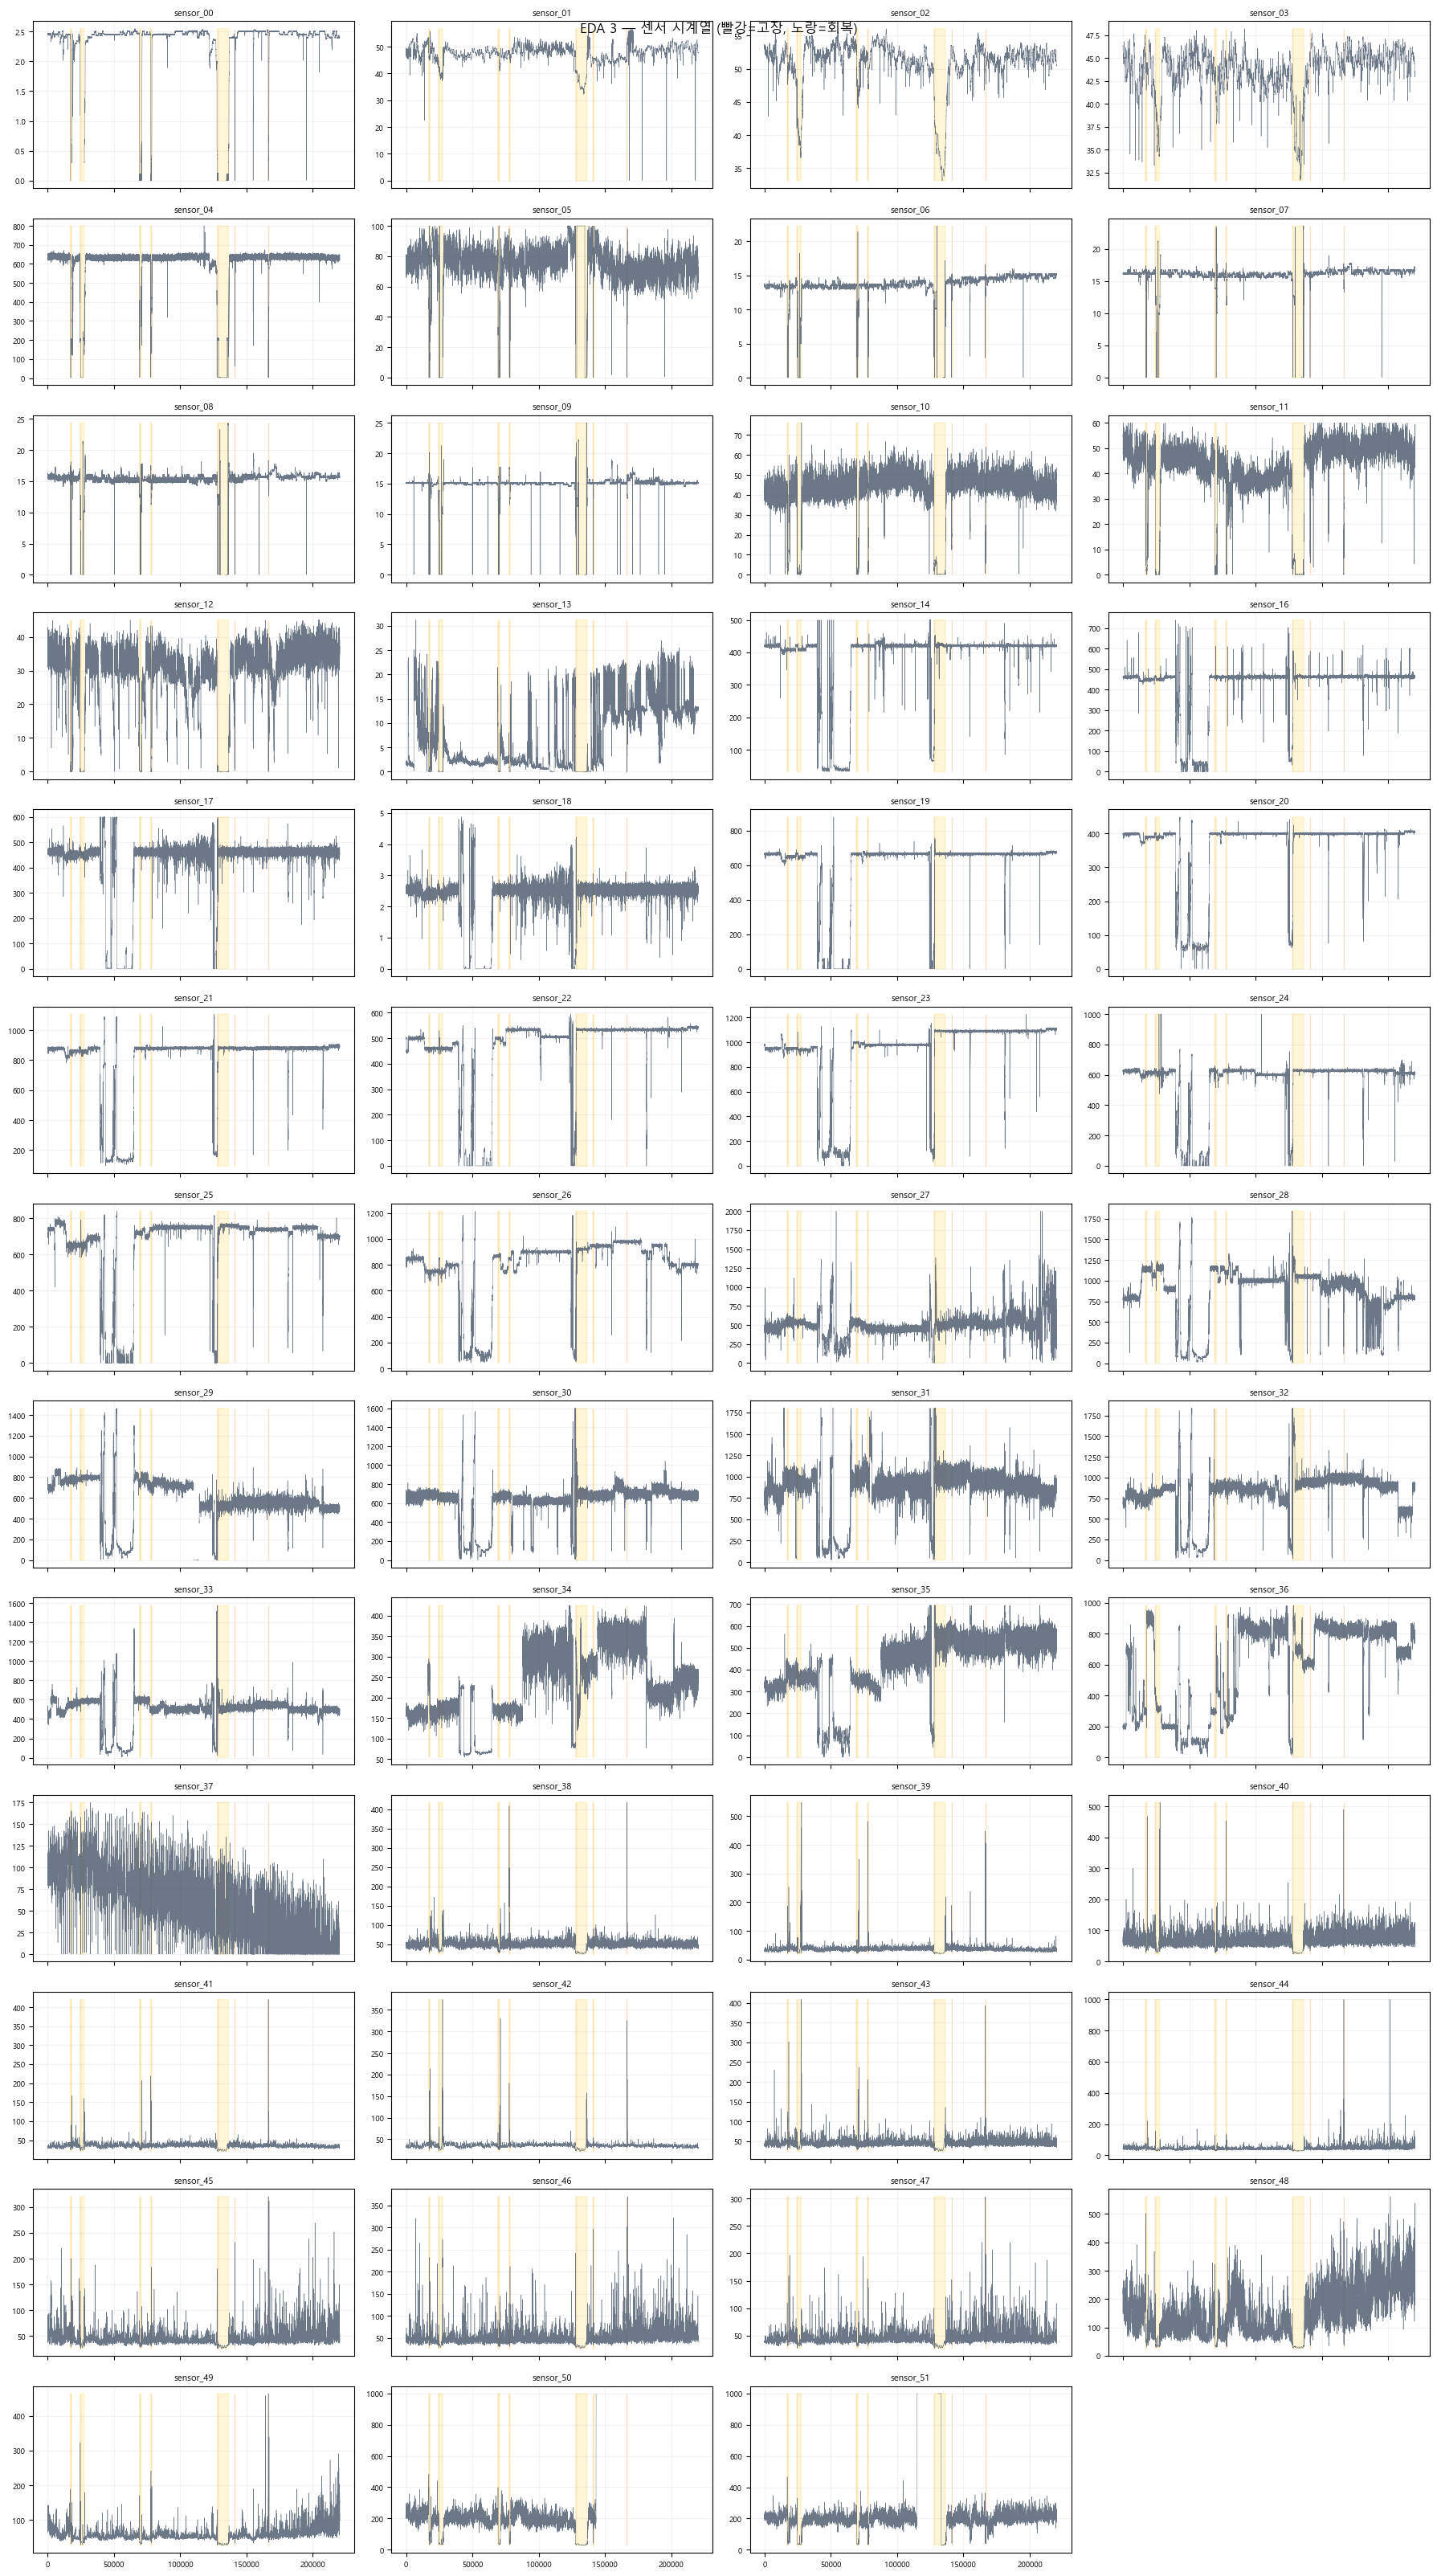

In [24]:
df_vis = df_raw[valid_sensors + ['machine_status']].copy()

n_col_plot = 4
n_row_plot = (len(valid_sensors) + n_col_plot - 1) // n_col_plot
fig, axes = plt.subplots(n_row_plot, n_col_plot,
                          figsize=(18, n_row_plot * 2.5), sharex=True)
axes = axes.flatten()

for idx, col in enumerate(valid_sensors):
    ax = axes[idx]
    ax.plot(range(len(df_vis)), df_vis[col].values,
            linewidth=0.35, color='#475569', alpha=0.8)
    for status, color in [('BROKEN','#FCA5A5'), ('RECOVERING','#FDE68A')]:
        mask = (df_vis['machine_status'] == status).values
        ax.fill_between(range(len(df_vis)),
                        df_vis[col].min(), df_vis[col].max(),
                        where=mask, alpha=0.35, color=color)
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.15)

for idx in range(len(valid_sensors), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('EDA 3 — 센서 시계열 (빨강=고장, 노랑=회복)',
             fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_all_sensors.png', dpi=110, bbox_inches='tight')
plt.show()


### ALL (51 sensors) — 03_ks_distribution


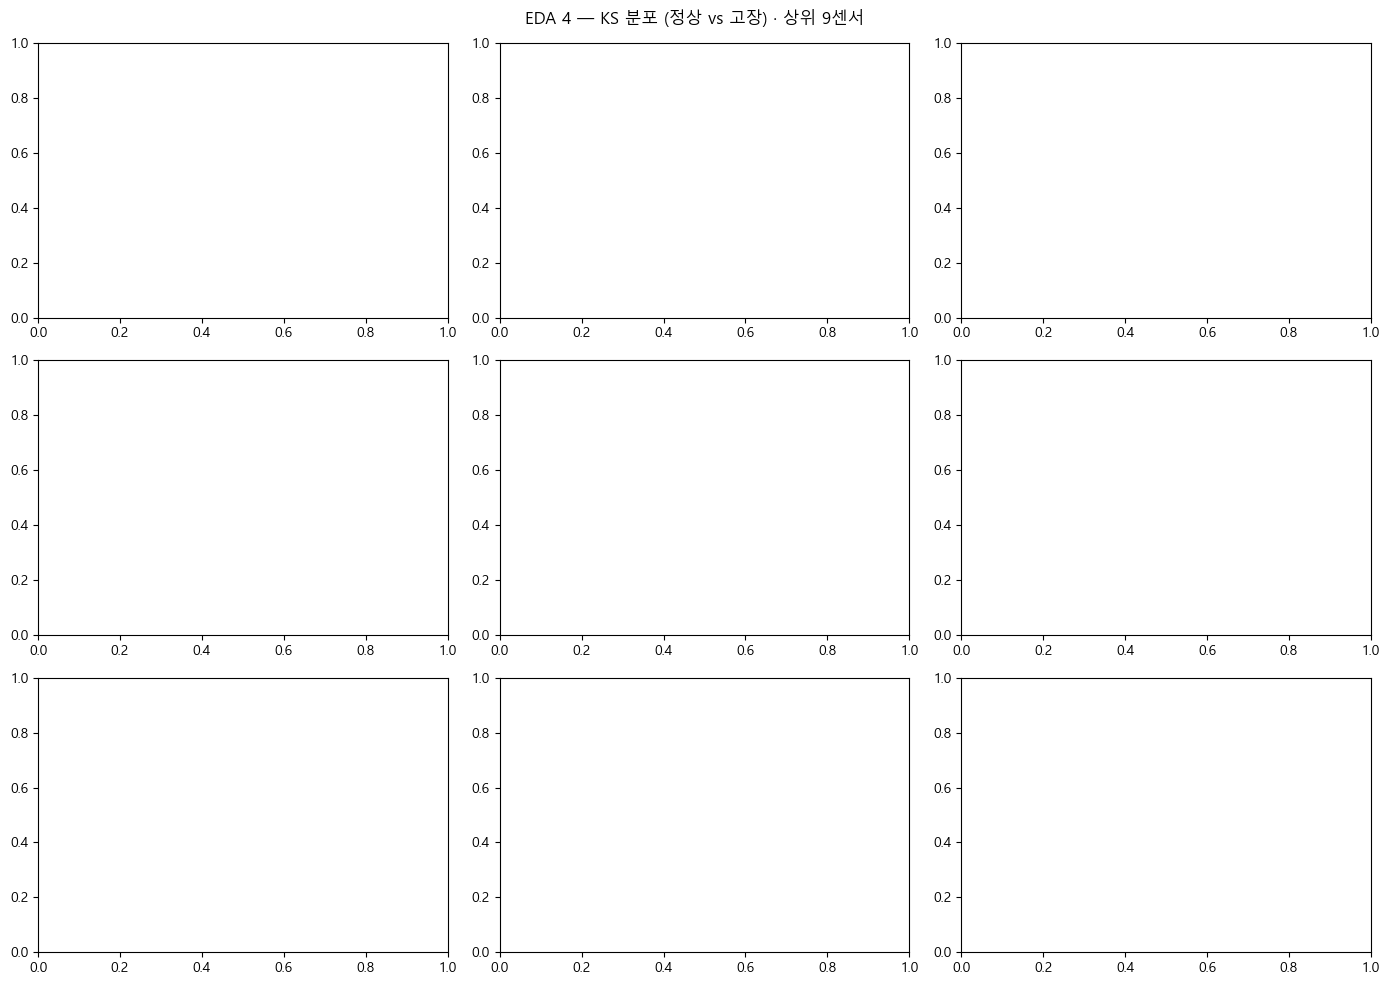

In [25]:
normal_df = df_vis[df_vis['machine_status']=='NORMAL'][valid_sensors]
broken_df = df_vis[df_vis['machine_status']=='BROKEN'][valid_sensors]

ks_scores = {}
for col in valid_sensors:
    a = normal_df[col].dropna()
    b = broken_df[col].dropna()
    if len(a) > 10 and len(b) > 10:
        stat, _ = stats.ks_2samp(a, b)
        ks_scores[col] = stat

top9 = sorted(ks_scores, key=ks_scores.get, reverse=True)[:9]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for idx, col in enumerate(top9):
    ax = axes[idx]
    ax.hist(normal_df[col].dropna(), bins=50, alpha=0.55,
            color='#93C5FD', label='정상', density=True)
    ax.hist(broken_df[col].dropna(), bins=50, alpha=0.55,
            color='#FCA5A5', label='고장', density=True)
    ax.set_title(f'{col}  KS={ks_scores[col]:.3f}', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
fig.suptitle('EDA 4 — KS 분포 (정상 vs 고장) · 상위 9센서', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_ks_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### ALL (51 sensors) — 04_adf


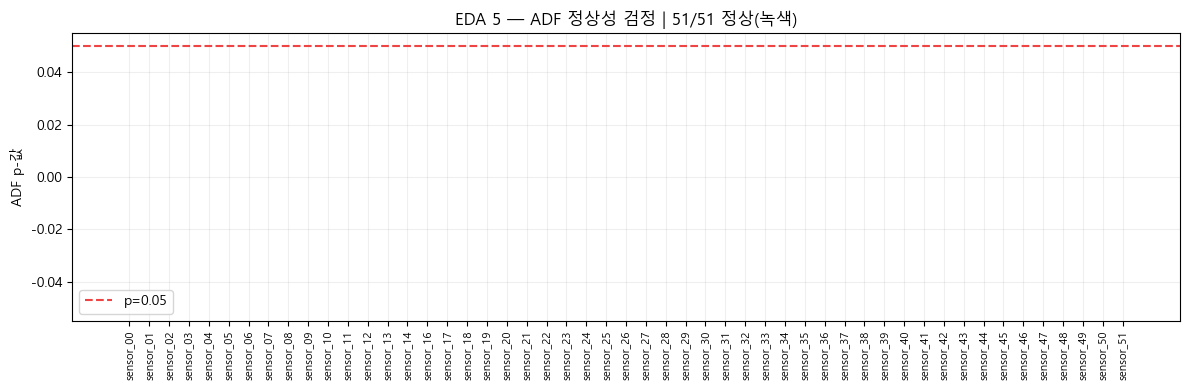

KeyError: "None of [Index([-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2,\n       -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2,\n       -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2],\n      dtype='object')] are in the [columns]"

In [26]:
sample_adf = df_vis[valid_sensors].dropna().sample(
    min(5000, len(df_vis)), random_state=SEED)

adf_res = {}
for col in valid_sensors:
    s = sample_adf[col].dropna()
    if len(s) < 20:
        continue
    try:
        result = adfuller(s, autolag='AIC')
        adf_res[col] = {'p': result[1], 'stationary': result[1] < 0.05}
    except Exception:
        pass

if not adf_res:
    print('ADF: 검정 가능한 센서가 없습니다 (04_adf.png 생략).')
else:
    adf_df = pd.DataFrame(adf_res).T
    if 'stationary' not in adf_df.columns:
        adf_df['stationary'] = False
    n_s = int(adf_df['stationary'].sum())

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(adf_df.index, adf_df['p'],
           color=['#6EE7B7' if s else '#FCA5A5' for s in adf_df['stationary']],
           width=0.7)
    ax.axhline(0.05, color='#EF4444', linestyle='--', lw=1.5, label='p=0.05')
    ax.set_ylabel('ADF p-값')
    ax.set_title(f'EDA 5 — ADF 정상성 검정 | {n_s}/{len(adf_df)} 정상(녹색)')
    ax.legend()
    ax.tick_params(axis='x', rotation=90, labelsize=8)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/04_adf.png', dpi=150, bbox_inches='tight')
    plt.show()

    non_stationary = adf_df[~adf_df['stationary'].astype(bool)].index.tolist()
    print(f'Non-stationary sensors: {non_stationary}')


### ALL (51 sensors) — 05_correlation


In [ ]:
corr_matrix = df_vis[valid_sensors].corr(method='pearson')

# 고상관 쌍 탐지
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        v = corr_matrix.iloc[i,j]
        if abs(v) > CORR_THRESH:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(v,4)))

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask,
            cmap=sns.diverging_palette(230,20,as_cmap=True),
            vmax=1, vmin=-1, center=0, square=True,
            linewidths=0.3, cbar_kws={'shrink':0.8}, ax=ax)
ax.set_title(f'EDA 6 — 피어슨 상관 히트맵 ({len(high_corr_pairs)}개 고상관 |r|>{CORR_THRESH})',
             fontsize=12)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'High-correlation pairs (|r|>{CORR_THRESH}):')
for a,b,v in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
    print(f'  {a} <-> {b} : r={v}')


### ALL (51 sensors) — 06_vif


In [ ]:
print('\n=== Iterative VIF Elimination ===')
selected_by_vif, vif_log = iterative_vif_drop(vif_sample, VIF_THRESH)

# 제로 분산 제거
zero_var = [c for c in selected_by_vif if df_vis[c].std() < 1e-6]
FINAL_FEATURES = [c for c in selected_by_vif if c not in zero_var]
N_FEATURES = len(FINAL_FEATURES)

vif_after = compute_vif(vif_sample[FINAL_FEATURES])

print(f'\n  Original   : {len(valid_sensors)} sensors')
print(f'  Dropped (VIF)    : {[c for c in valid_sensors if c not in selected_by_vif]}')
print(f'  Dropped (zero-var): {zero_var}')
print(f'  FINAL : {N_FEATURES} features')
print(f'\nFinal features: {FINAL_FEATURES}')

# VIF 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax_i, (vdf, title_s) in enumerate([
    (vif_before, f'Before ({len(valid_sensors)} features)'),
    (vif_after,  f'After ({N_FEATURES} features)')]):
    ax = axes[ax_i]
    c = ['#EF4444' if v>10 else '#F59E0B' if v>5 else '#6EE7B7' for v in vdf['VIF']]
    ax.barh(vdf['feature'], vdf['VIF'], color=c, height=0.7)
    ax.axvline(VIF_THRESH, color='#EF4444', linestyle='--', lw=1.5,
               label=f'임계값 ({VIF_THRESH})')
    ax.set_xlabel('VIF')
    ax.set_title(f'피처 선택 — VIF {title_s}')
    ax.legend(fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_vif.png', dpi=150, bbox_inches='tight')
plt.show()


### ALL (51 sensors) — 07_window_dist


In [ ]:
def make_windows(data, labels, win, step):
    """
    Sliding window 생성.
    window 내 이상 레이블이 하나라도 있으면 해당 window = 이상(1)
    Returns: X (N, win, feat), y (N,)
    """
    X, y = [], []
    for s in range(0, len(data) - win, step):
        X.append(data[s:s+win])
        y.append(int(labels[s:s+win].max()))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


X_train_all, y_train_all = make_windows(train_scaled, labels_train, WINDOW_SIZE, STEP_SIZE)
X_val_all, y_val_all = make_windows(val_scaled, labels_val, WINDOW_SIZE, STEP_SIZE)
X_test, y_test = make_windows(test_scaled, labels_test, WINDOW_SIZE, STEP_SIZE)

normal_idx = np.where(y_train_all == 0)[0]
X_train = X_train_all[normal_idx]

X_train_t = torch.FloatTensor(X_train).to(device)
X_val_t = torch.FloatTensor(X_val_all).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)

# (visualization_only) 학습 로더 생략
print('Window tensors ready for checkpoint eval.')


### ALL (51 sensors) — 08_model_comparison


In [ ]:
# ── 성능 비교 시각화 ───────────────────────────────────────────────
model_names  = list(results.keys())
metrics_keys = ['f1','f2','precision','recall','roc_auc','pr_auc']
mtitles      = ['F1','F2(β=2)','Precision','Recall','ROC-AUC','PR-AUC']
plot_keys    = ['f2','f1','precision','recall','roc_auc']
plot_titles  = ['F2 (선정·튜닝과 동일)','F1','정밀도','재현율','ROC-AUC']

comp_df = pd.DataFrame(
    {k: {m: round(results[m][k],4) for m in model_names} for k in metrics_keys}
).T
print('\n=== Model Comparison (metrics on hold-out TEST — reference only; selection uses VAL) ===')
print(comp_df.to_string())

fig = plt.figure(figsize=(18,9))
gs  = gridspec.GridSpec(2,3, figure=fig, hspace=0.45, wspace=0.35)

for mi,(key,title) in enumerate(zip(plot_keys, plot_titles)):
    ax = fig.add_subplot(gs[mi//3, mi%3])
    vals = [results[m][key] for m in model_names]
    bars = ax.bar(model_names, vals, color=plot_colors[:len(model_names)],
                  width=0.55, edgecolor='white')
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0,1.15); ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=20, labelsize=9); ax.grid(True, alpha=0.2, axis='y')

ax_t = fig.add_subplot(gs[1,2])
ax_t.bar(model_names, [results[m]['train_time'] for m in model_names],
         color=plot_colors[:len(model_names)], width=0.55, edgecolor='white')
ax_t.set_title('학습 시간 (초)', fontsize=11, fontweight='bold')
ax_t.tick_params(axis='x', rotation=20, labelsize=9); ax_t.grid(True, alpha=0.2, axis='y')

fig.suptitle('5종 모델 성능 비교', fontsize=13)
plt.savefig(f'{OUTPUT_DIR}/08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC 곡선
fig, ax = plt.subplots(figsize=(8,6))
for i,mname in enumerate(model_names):
    fpr,tpr,_ = roc_curve(y_test, results[mname]['errors'])
    ax.plot(fpr,tpr, color=plot_colors[i], lw=2,
            label=f'{mname} (AUC={results[mname]["roc_auc"]:.3f})')
ax.plot([0,1],[0,1],'k--',lw=0.8)
ax.set_xlabel('FPR(위양성 비율)'); ax.set_ylabel('TPR(재현율)')
ax.set_title('모델별 ROC 곡선'); ax.legend(fontsize=9); ax.grid(True,alpha=0.2)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_roc.png', dpi=150, bbox_inches='tight')
plt.show()


### ALL (51 sensors) — 09_roc


In [ ]:
# Optuna 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 최적화 히스토리
# trial_vals: prepare_variant()가 체크포인트 .log에서 파싱
axes[0].plot(trial_vals, 'o-', color='#6366F1', markersize=4, lw=1.5)
best_f2 = study_best_value if study_best_value is not None else (max(trial_vals) if trial_vals else 0)
axes[0].axhline(best_f2, color='#EF4444', linestyle='--',
                label=f'최적 F2={best_f2:.4f}')
axes[0].axhline(results[BEST_MODEL_NAME]['val_f2'], color='#94A3B8',
                linestyle=':', label=f'6절 기본 검증 F2={results[BEST_MODEL_NAME]["val_f2"]:.4f}')
axes[0].set_title(f'Optuna 최적화 이력 — {BEST_MODEL_NAME}')
axes[0].set_xlabel('시행'); axes[0].set_ylabel('검증 F2 (β=2)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.2)

# 파라미터 중요도
try:
    imp = {}
    ks_i = list(imp.keys())[:8]; vs_i = [imp[k] for k in ks_i]
    axes[1].barh(ks_i, vs_i, color='#10B981', height=0.6)
    axes[1].set_title('하이퍼파라미터 중요도')
    axes[1].grid(True, alpha=0.2)
except Exception:
    axes[1].text(0.5, 0.5, 'Need more trials', ha='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/10_optuna.png', dpi=150, bbox_inches='tight')
plt.show()


### ALL (51 sensors) — 10_optuna


In [ ]:
# 최종 결과 종합 시각화
fig, axes = plt.subplots(3, 1, figsize=(16,11), sharex=True)
idx  = np.arange(len(final_errors))
thr  = final_metrics['threshold']

axes[0].plot(idx, final_errors, color='#6366F1', lw=0.5, alpha=0.9)
axes[0].axhline(thr, color='#EF4444', lw=2, linestyle='--', label=f'임계값={thr:.4f}')
axes[0].fill_between(idx, final_errors, thr,
                     where=final_errors>thr, alpha=0.4, color='#F59E0B')
axes[0].set_ylabel('재구성 오차')
axes[0].set_title(f'{BEST_MODEL_NAME} (Tuned) — F1={final_metrics["f1"]:.4f}  ROC-AUC={final_metrics["roc_auc"]:.4f}',
                  fontsize=12)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.2)

axes[1].fill_between(idx, 0, 1, where=y_te_fin==1,
                     alpha=0.6, color='#EF4444', label='실제 이상')
axes[1].fill_between(idx, 0, 1, where=final_metrics['y_pred']==1,
                     alpha=0.35, color='#F59E0B', label='예측')
axes[1].set_ylabel('이상'); axes[1].set_yticks([])
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.2)

prec,rec,thrs = precision_recall_curve(y_te_fin, final_errors)
f1c = 2*prec*rec/(prec+rec+1e-9)
axes[2].plot(thrs, prec[:-1], color='#10B981', lw=1.5, label='정밀도')
axes[2].plot(thrs, rec[:-1],  color='#6366F1', lw=1.5, label='재현율')
axes[2].plot(thrs, f1c[:-1],  color='#F59E0B', lw=2,   linestyle='--', label='F1 점수')
axes[2].axvline(thr, color='#EF4444', linestyle='--', lw=1.5, label='최적 임계값')
axes[2].set_xlabel('임계값')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.2)
axes[2].set_title('정밀도 / 재현율 / F1 vs 임계값')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_final_result.png', dpi=150, bbox_inches='tight')
plt.show()


---
## VIF (~21 sensors)


In [ ]:
prepare_variant('vif')


### VIF (~21 sensors) — 01_missing_labels


In [ ]:
missing = df_raw[sensor_cols].isnull().mean().sort_values(ascending=False)
drop_missing = missing[missing > MISSING_THRESH].index.tolist()
valid_sensors = [c for c in sensor_cols if c not in drop_missing]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 결측률 바차트
ax = axes[0]
colors = ['#EF4444' if v > MISSING_THRESH else '#93C5FD' if v > 0.2 else '#6EE7B7'
          for v in missing.values]
ax.barh(missing.index, missing.values * 100, color=colors, height=0.7)
ax.axvline(MISSING_THRESH * 100, color='#EF4444', linestyle='--', lw=1.5,
           label=f'제거 임계값 ({int(MISSING_THRESH*100)}%)')
ax.set_xlabel('결측 비율 (%)')
ax.set_title('EDA 1 — 센서별 결측 비율 (빨강=제거)')
ax.legend(fontsize=9)
ax.tick_params(axis='y', labelsize=7)

# 레이블 분포
vc = df_raw['machine_status'].value_counts()
label_ko = {'NORMAL': '정상', 'BROKEN': '고장', 'RECOVERING': '회복'}
bar_col = {'NORMAL':'#6EE7B7', 'BROKEN':'#FCA5A5', 'RECOVERING':'#FDE68A'}
ax2 = axes[1]
ax2.bar([label_ko.get(str(k), str(k)) for k in vc.index], vc.values,
        color=[bar_col.get(str(k),'#CBD5E1') for k in vc.index], edgecolor='white', width=0.5)
for i,(k,v) in enumerate(vc.items()):
    ax2.text(i, v+500, f'{v:,}\n({v/len(df_raw)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10)
ax2.set_title('EDA 2 — 라벨 분포')
ax2.set_ylabel('개수')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_missing_labels.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Dropped by missing: {drop_missing}')
print(f'Remaining sensors : {len(valid_sensors)}')


### VIF (~21 sensors) — 02_all_sensors


In [ ]:
df_vis = df_raw[valid_sensors + ['machine_status']].copy()

n_col_plot = 4
n_row_plot = (len(valid_sensors) + n_col_plot - 1) // n_col_plot
fig, axes = plt.subplots(n_row_plot, n_col_plot,
                          figsize=(18, n_row_plot * 2.5), sharex=True)
axes = axes.flatten()

for idx, col in enumerate(valid_sensors):
    ax = axes[idx]
    ax.plot(range(len(df_vis)), df_vis[col].values,
            linewidth=0.35, color='#475569', alpha=0.8)
    for status, color in [('BROKEN','#FCA5A5'), ('RECOVERING','#FDE68A')]:
        mask = (df_vis['machine_status'] == status).values
        ax.fill_between(range(len(df_vis)),
                        df_vis[col].min(), df_vis[col].max(),
                        where=mask, alpha=0.35, color=color)
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.15)

for idx in range(len(valid_sensors), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('EDA 3 — 센서 시계열 (빨강=고장, 노랑=회복)',
             fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_all_sensors.png', dpi=110, bbox_inches='tight')
plt.show()


### VIF (~21 sensors) — 03_ks_distribution


In [ ]:
normal_df = df_vis[df_vis['machine_status']=='NORMAL'][valid_sensors]
broken_df = df_vis[df_vis['machine_status']=='BROKEN'][valid_sensors]

ks_scores = {}
for col in valid_sensors:
    a = normal_df[col].dropna()
    b = broken_df[col].dropna()
    if len(a) > 10 and len(b) > 10:
        stat, _ = stats.ks_2samp(a, b)
        ks_scores[col] = stat

top9 = sorted(ks_scores, key=ks_scores.get, reverse=True)[:9]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for idx, col in enumerate(top9):
    ax = axes[idx]
    ax.hist(normal_df[col].dropna(), bins=50, alpha=0.55,
            color='#93C5FD', label='정상', density=True)
    ax.hist(broken_df[col].dropna(), bins=50, alpha=0.55,
            color='#FCA5A5', label='고장', density=True)
    ax.set_title(f'{col}  KS={ks_scores[col]:.3f}', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
fig.suptitle('EDA 4 — KS 분포 (정상 vs 고장) · 상위 9센서', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_ks_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### VIF (~21 sensors) — 04_adf


In [ ]:
sample_adf = df_vis[valid_sensors].dropna().sample(
    min(5000, len(df_vis)), random_state=SEED)

adf_res = {}
for col in valid_sensors:
    s = sample_adf[col].dropna()
    if len(s) < 20:
        continue
    try:
        result = adfuller(s, autolag='AIC')
        adf_res[col] = {'p': result[1], 'stationary': result[1] < 0.05}
    except Exception:
        pass

if not adf_res:
    print('ADF: 검정 가능한 센서가 없습니다 (04_adf.png 생략).')
else:
    adf_df = pd.DataFrame(adf_res).T
    if 'stationary' not in adf_df.columns:
        adf_df['stationary'] = False
    n_s = int(adf_df['stationary'].sum())

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(adf_df.index, adf_df['p'],
           color=['#6EE7B7' if s else '#FCA5A5' for s in adf_df['stationary']],
           width=0.7)
    ax.axhline(0.05, color='#EF4444', linestyle='--', lw=1.5, label='p=0.05')
    ax.set_ylabel('ADF p-값')
    ax.set_title(f'EDA 5 — ADF 정상성 검정 | {n_s}/{len(adf_df)} 정상(녹색)')
    ax.legend()
    ax.tick_params(axis='x', rotation=90, labelsize=8)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/04_adf.png', dpi=150, bbox_inches='tight')
    plt.show()

    non_stationary = adf_df[~adf_df['stationary'].astype(bool)].index.tolist()
    print(f'Non-stationary sensors: {non_stationary}')


### VIF (~21 sensors) — 05_correlation


In [ ]:
corr_matrix = df_vis[valid_sensors].corr(method='pearson')

# 고상관 쌍 탐지
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        v = corr_matrix.iloc[i,j]
        if abs(v) > CORR_THRESH:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(v,4)))

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask,
            cmap=sns.diverging_palette(230,20,as_cmap=True),
            vmax=1, vmin=-1, center=0, square=True,
            linewidths=0.3, cbar_kws={'shrink':0.8}, ax=ax)
ax.set_title(f'EDA 6 — 피어슨 상관 히트맵 ({len(high_corr_pairs)}개 고상관 |r|>{CORR_THRESH})',
             fontsize=12)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'High-correlation pairs (|r|>{CORR_THRESH}):')
for a,b,v in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
    print(f'  {a} <-> {b} : r={v}')


### VIF (~21 sensors) — 06_vif


In [ ]:
print('\n=== Iterative VIF Elimination ===')
selected_by_vif, vif_log = iterative_vif_drop(vif_sample, VIF_THRESH)

# 제로 분산 제거
zero_var = [c for c in selected_by_vif if df_vis[c].std() < 1e-6]
FINAL_FEATURES = [c for c in selected_by_vif if c not in zero_var]
N_FEATURES = len(FINAL_FEATURES)

vif_after = compute_vif(vif_sample[FINAL_FEATURES])

print(f'\n  Original   : {len(valid_sensors)} sensors')
print(f'  Dropped (VIF)    : {[c for c in valid_sensors if c not in selected_by_vif]}')
print(f'  Dropped (zero-var): {zero_var}')
print(f'  FINAL : {N_FEATURES} features')
print(f'\nFinal features: {FINAL_FEATURES}')

# VIF 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax_i, (vdf, title_s) in enumerate([
    (vif_before, f'Before ({len(valid_sensors)} features)'),
    (vif_after,  f'After ({N_FEATURES} features)')]):
    ax = axes[ax_i]
    c = ['#EF4444' if v>10 else '#F59E0B' if v>5 else '#6EE7B7' for v in vdf['VIF']]
    ax.barh(vdf['feature'], vdf['VIF'], color=c, height=0.7)
    ax.axvline(VIF_THRESH, color='#EF4444', linestyle='--', lw=1.5,
               label=f'임계값 ({VIF_THRESH})')
    ax.set_xlabel('VIF')
    ax.set_title(f'피처 선택 — VIF {title_s}')
    ax.legend(fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_vif.png', dpi=150, bbox_inches='tight')
plt.show()


### VIF (~21 sensors) — 07_window_dist


In [ ]:
def make_windows(data, labels, win, step):
    """
    Sliding window 생성.
    window 내 이상 레이블이 하나라도 있으면 해당 window = 이상(1)
    Returns: X (N, win, feat), y (N,)
    """
    X, y = [], []
    for s in range(0, len(data) - win, step):
        X.append(data[s:s+win])
        y.append(int(labels[s:s+win].max()))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


X_train_all, y_train_all = make_windows(train_scaled, labels_train, WINDOW_SIZE, STEP_SIZE)
X_val_all, y_val_all = make_windows(val_scaled, labels_val, WINDOW_SIZE, STEP_SIZE)
X_test, y_test = make_windows(test_scaled, labels_test, WINDOW_SIZE, STEP_SIZE)

normal_idx = np.where(y_train_all == 0)[0]
X_train = X_train_all[normal_idx]

X_train_t = torch.FloatTensor(X_train).to(device)
X_val_t = torch.FloatTensor(X_val_all).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)

# (visualization_only) 학습 로더 생략
print('Window tensors ready for checkpoint eval.')


### VIF (~21 sensors) — 08_model_comparison


In [ ]:
# ── 성능 비교 시각화 ───────────────────────────────────────────────
model_names  = list(results.keys())
metrics_keys = ['f1','f2','precision','recall','roc_auc','pr_auc']
mtitles      = ['F1','F2(β=2)','Precision','Recall','ROC-AUC','PR-AUC']
plot_keys    = ['f2','f1','precision','recall','roc_auc']
plot_titles  = ['F2 (선정·튜닝과 동일)','F1','정밀도','재현율','ROC-AUC']

comp_df = pd.DataFrame(
    {k: {m: round(results[m][k],4) for m in model_names} for k in metrics_keys}
).T
print('\n=== Model Comparison (metrics on hold-out TEST — reference only; selection uses VAL) ===')
print(comp_df.to_string())

fig = plt.figure(figsize=(18,9))
gs  = gridspec.GridSpec(2,3, figure=fig, hspace=0.45, wspace=0.35)

for mi,(key,title) in enumerate(zip(plot_keys, plot_titles)):
    ax = fig.add_subplot(gs[mi//3, mi%3])
    vals = [results[m][key] for m in model_names]
    bars = ax.bar(model_names, vals, color=plot_colors[:len(model_names)],
                  width=0.55, edgecolor='white')
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0,1.15); ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=20, labelsize=9); ax.grid(True, alpha=0.2, axis='y')

ax_t = fig.add_subplot(gs[1,2])
ax_t.bar(model_names, [results[m]['train_time'] for m in model_names],
         color=plot_colors[:len(model_names)], width=0.55, edgecolor='white')
ax_t.set_title('학습 시간 (초)', fontsize=11, fontweight='bold')
ax_t.tick_params(axis='x', rotation=20, labelsize=9); ax_t.grid(True, alpha=0.2, axis='y')

fig.suptitle('5종 모델 성능 비교', fontsize=13)
plt.savefig(f'{OUTPUT_DIR}/08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC 곡선
fig, ax = plt.subplots(figsize=(8,6))
for i,mname in enumerate(model_names):
    fpr,tpr,_ = roc_curve(y_test, results[mname]['errors'])
    ax.plot(fpr,tpr, color=plot_colors[i], lw=2,
            label=f'{mname} (AUC={results[mname]["roc_auc"]:.3f})')
ax.plot([0,1],[0,1],'k--',lw=0.8)
ax.set_xlabel('FPR(위양성 비율)'); ax.set_ylabel('TPR(재현율)')
ax.set_title('모델별 ROC 곡선'); ax.legend(fontsize=9); ax.grid(True,alpha=0.2)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_roc.png', dpi=150, bbox_inches='tight')
plt.show()


### VIF (~21 sensors) — 09_roc


In [ ]:
# Optuna 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 최적화 히스토리
# trial_vals: prepare_variant()가 체크포인트 .log에서 파싱
axes[0].plot(trial_vals, 'o-', color='#6366F1', markersize=4, lw=1.5)
best_f2 = study_best_value if study_best_value is not None else (max(trial_vals) if trial_vals else 0)
axes[0].axhline(best_f2, color='#EF4444', linestyle='--',
                label=f'최적 F2={best_f2:.4f}')
axes[0].axhline(results[BEST_MODEL_NAME]['val_f2'], color='#94A3B8',
                linestyle=':', label=f'6절 기본 검증 F2={results[BEST_MODEL_NAME]["val_f2"]:.4f}')
axes[0].set_title(f'Optuna 최적화 이력 — {BEST_MODEL_NAME}')
axes[0].set_xlabel('시행'); axes[0].set_ylabel('검증 F2 (β=2)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.2)

# 파라미터 중요도
try:
    imp = {}
    ks_i = list(imp.keys())[:8]; vs_i = [imp[k] for k in ks_i]
    axes[1].barh(ks_i, vs_i, color='#10B981', height=0.6)
    axes[1].set_title('하이퍼파라미터 중요도')
    axes[1].grid(True, alpha=0.2)
except Exception:
    axes[1].text(0.5, 0.5, 'Need more trials', ha='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/10_optuna.png', dpi=150, bbox_inches='tight')
plt.show()


### VIF (~21 sensors) — 10_optuna


In [ ]:
# 최종 결과 종합 시각화
fig, axes = plt.subplots(3, 1, figsize=(16,11), sharex=True)
idx  = np.arange(len(final_errors))
thr  = final_metrics['threshold']

axes[0].plot(idx, final_errors, color='#6366F1', lw=0.5, alpha=0.9)
axes[0].axhline(thr, color='#EF4444', lw=2, linestyle='--', label=f'임계값={thr:.4f}')
axes[0].fill_between(idx, final_errors, thr,
                     where=final_errors>thr, alpha=0.4, color='#F59E0B')
axes[0].set_ylabel('재구성 오차')
axes[0].set_title(f'{BEST_MODEL_NAME} (Tuned) — F1={final_metrics["f1"]:.4f}  ROC-AUC={final_metrics["roc_auc"]:.4f}',
                  fontsize=12)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.2)

axes[1].fill_between(idx, 0, 1, where=y_te_fin==1,
                     alpha=0.6, color='#EF4444', label='실제 이상')
axes[1].fill_between(idx, 0, 1, where=final_metrics['y_pred']==1,
                     alpha=0.35, color='#F59E0B', label='예측')
axes[1].set_ylabel('이상'); axes[1].set_yticks([])
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.2)

prec,rec,thrs = precision_recall_curve(y_te_fin, final_errors)
f1c = 2*prec*rec/(prec+rec+1e-9)
axes[2].plot(thrs, prec[:-1], color='#10B981', lw=1.5, label='정밀도')
axes[2].plot(thrs, rec[:-1],  color='#6366F1', lw=1.5, label='재현율')
axes[2].plot(thrs, f1c[:-1],  color='#F59E0B', lw=2,   linestyle='--', label='F1 점수')
axes[2].axvline(thr, color='#EF4444', linestyle='--', lw=1.5, label='최적 임계값')
axes[2].set_xlabel('임계값')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.2)
axes[2].set_title('정밀도 / 재현율 / F1 vs 임계값')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_final_result.png', dpi=150, bbox_inches='tight')
plt.show()
